In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score


In [2]:
df = pd.read_excel("/content/Employee_Data.xlsx")
df.head()


,Employee_ID,Name,Department,Role,Experience_Years,Base_Salary,Performance_Rating,Targets_Assigned,Targets_Achieved,Leaves_Taken,Working_Days,Performance %,Attendance %,Bonus,Incentive,Final Salary,Reward Status
0,E001,Employee_1,HR,Analyst,2,30000,2,100,61,1,22,0.61,0.954545,1500,0,31500,Bonus Eligible
1,E002,Employee_2,Sales,Manager,3,35000,3,100,62,2,22,0.62,0.909091,1750,0,36750,Bonus Eligible
2,E003,Employee_3,Finance,Engineer,4,40000,4,100,63,3,22,0.63,0.863636,2000,0,42000,Bonus Eligible
3,E004,Employee_4,Operations,Associate,5,45000,5,100,64,4,22,0.64,0.818182,2250,0,47250,Bonus Eligible
4,E005,Employee_5,IT,Executive,6,50000,1,100,65,5,22,0.65,0.772727,2500,0,52500,Bonus Eligible


In [3]:
df.info()
df.isnull().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Employee_ID         50 non-null     object 
 1   Name                50 non-null     object 
 2   Department          50 non-null     object 
 3   Role                50 non-null     object 
 4   Experience_Years    50 non-null     int64  
 5   Base_Salary         50 non-null     int64  
 6   Performance_Rating  50 non-null     int64  
 7   Targets_Assigned    50 non-null     int64  
 8   Targets_Achieved    50 non-null     int64  
 9   Leaves_Taken        50 non-null     int64  
 10  Working_Days        50 non-null     int64  
 11  Performance %       50 non-null     float64
 12  Attendance %        50 non-null     float64
 13  Bonus               50 non-null     int64  
 14  Incentive           50 non-null     int64  
 15  Final Salary        50 non-null     int64  
 16  Reward Sta

,0
Employee_ID,0
Name,0
Department,0
Role,0
Experience_Years,0
Base_Salary,0
Performance_Rating,0
Targets_Assigned,0
Targets_Achieved,0
Leaves_Taken,0


In [4]:
X = df[
    [
        'Experience_Years',
        'Targets_Assigned',
        'Targets_Achieved',
        'Leaves_Taken',
        'Attendance %'
    ]
]

y = df['Performance %']


In [5]:
#Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [6]:
# 6. Model creation & training
model = LinearRegression()
model.fit(X_train, y_train)


LinearRegression()

In [7]:
# 7. Prediction
y_pred = model.predict(X_test)


In [8]:
# 8. Model evaluation
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("R2 Score:", r2)


Mean Squared Error: 3.697785493223493e-33
R2 Score: 1.0


In [9]:
# 9. Actual vs Predicted comparison
result = pd.DataFrame({
    'Actual Performance %': y_test,
    'Predicted Performance %': y_pred
})

result.head()


,Actual Performance %,Predicted Performance %
13,0.74,0.74
39,1.00,1.00
30,0.91,0.91
45,0.65,0.65
17,0.78,0.78


In [10]:
X = df.drop('Performance %', axis=1)
y = df['Performance %']


In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [20]:
result = pd.DataFrame({
    'Actual Performance %': y_test,
    'Predicted Performance %': y_pred
})

result.head()


,Actual Performance %,Predicted Performance %
13,0.74,0.74
39,1.00,1.00
30,0.91,0.91
45,0.65,0.65
17,0.78,0.78


In [21]:
print(X.columns)


Index(['Employee_ID', 'Name', 'Department', 'Role', 'Experience_Years',
       'Base_Salary', 'Performance_Rating', 'Targets_Assigned',
       'Targets_Achieved', 'Leaves_Taken', 'Working_Days', 'Attendance %',
       'Bonus', 'Incentive', 'Final Salary', 'Reward Status'],
      dtype='object')


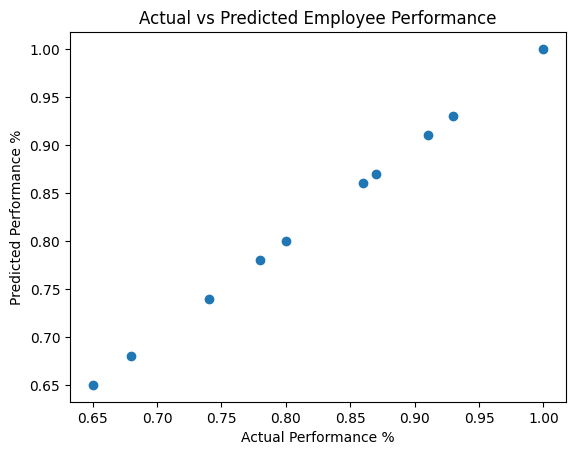

In [22]:
import matplotlib.pyplot as plt
plt.figure()
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Performance %")
plt.ylabel("Predicted Performance %")
plt.title("Actual vs Predicted Employee Performance")
plt.show()


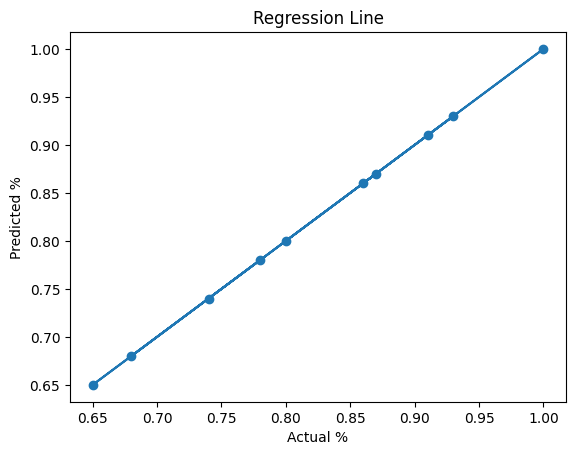

In [23]:
import matplotlib.pyplot as plt
import numpy as np

plt.scatter(y_test, y_pred)
m, b = np.polyfit(y_test, y_pred, 1)
plt.plot(y_test, m*y_test + b)

plt.xlabel("Actual %")
plt.ylabel("Predicted %")
plt.title("Regression Line")
plt.show()


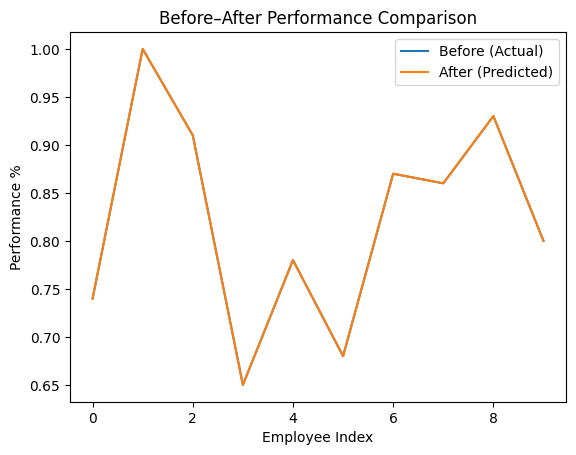

In [24]:
import matplotlib.pyplot as plt
plt.figure()
plt.plot(y_test.values, label="Before (Actual)")
plt.plot(y_pred, label="After (Predicted)")
plt.xlabel("Employee Index")
plt.ylabel("Performance %")
plt.title("Before–After Performance Comparison")
plt.legend()
plt.show()
